In [686]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
import pandas as pd
from scipy.optimize import minimize, minimize_scalar
from scipy.integrate import quad  # 引入积分模块
import time

try:
    from IPython.display import display
except ImportError:
    display = print

In [687]:
q = 1.0              # total demand

# FW outer-loop parameters
fw_tol = 1e-4
fw_max_iter = 200

# line-search parameters
eps_ls = 1e-4
alpha_max = 1.0

In [688]:
# define cost functions
def t1(x1):
    return x1

def t2(x2):
    return x2

def t3(x3):
    return x3 + 1.0


# define cost vectors
def C(x):
    return np.array(
        [t1(x[0]), t2(x[1]), t3(x[2])]
    )

# define Beckmann function
def Z(x):
    return 0.5*x[0]**2 + 0.5 * x[1]**2 + 0.5 * x[2] **2 +x[2]

# define AON assignment
def AON(cost):
    y = np.zeros_like(cost)
    shortest_path_index = np.argmin(cost)
    y[shortest_path_index] = q
    return y


In [689]:
'''
x1, x2, x3 = 0, 0, 0
x_free = np.array([x1, x2, x3])
print(x_free)
free_cost = C(x_free)
x = AON(free_cost)
print(free_cost)
print(x)
'''

'\nx1, x2, x3 = 0, 0, 0\nx_free = np.array([x1, x2, x3])\nprint(x_free)\nfree_cost = C(x_free)\nx = AON(free_cost)\nprint(free_cost)\nprint(x)\n'

In [690]:
x1, x2, x3 = 0.2, 0.6, 0.2
x = np.array([x1, x2, x3])
cost = C(x)
y = AON(cost)
d = y - x
print(cost)
print(y)
print(d)

[0.2 0.6 1.2]
[1. 0. 0.]
[ 0.8 -0.6 -0.2]


In [691]:
def x_alpha(x, d, alpha):
    return x + alpha * d

In [692]:
print(x_alpha(x, d, 0.0))
print(x_alpha(x, d, 0.5))
print(x_alpha(x, d, 1.0))

[0.2 0.6 0.2]
[0.6 0.3 0.1]
[1. 0. 0.]


In [693]:
def phi(x, d, alpha):
    return Z(x_alpha(x, d, alpha))

In [694]:
print(phi(x, d, 0.0))
print(phi(x, d, 0.5))
print(phi(x, d, 1.0))

0.42000000000000004
0.33000000000000007
0.5


In [695]:
def phi_prime(x, d, alpha):
    return np.dot(C(x_alpha(x, d, alpha)), d)

In [696]:
print(phi_prime(x, d, 0.0))
print(phi_prime(x, d, 0.5))
print(phi_prime(x, d, 1.0))


-0.43999999999999995
0.08000000000000007
0.6000000000000001


In [697]:
# vibe version for bisection
'''
def line_search_bisection(x, d, eps_ls, a=0.0, b=1.0, line_max_iter=100):
    line_start_time = time.perf_counter()

    left = a
    right = b

    n_ls = 0
    derivative_evals = 0

    # evaluate phi'(left)
    g_left = phi_prime(x, d, left)
    derivative_evals += 1

    if g_left >= 0:
        alpha = left
        line_runtime = time.perf_counter() - line_start_time
        return alpha, n_ls, derivative_evals, line_runtime

    # evaluate phi'(right)
    g_right = phi_prime(x, d, right)
    derivative_evals += 1

    if g_right <= 0:
        alpha = right
        line_runtime = time.perf_counter() - line_start_time
        return alpha, n_ls, derivative_evals, line_runtime

    # bisection interval reduction
    while (right - left) > 2.0 * eps_ls and n_ls < line_max_iter:
        mid = (left + right) / 2.0

        # evaluate phi'(mid) only once
        g_mid = phi_prime(x, d, mid)
        derivative_evals += 1

        if g_mid < 0:
            left = mid
        else:
            right = mid

        n_ls += 1

    alpha = (left + right) / 2.0

    line_runtime = time.perf_counter() - line_start_time

    return alpha, n_ls, derivative_evals, line_runtime
'''

"\ndef line_search_bisection(x, d, eps_ls, a=0.0, b=1.0, line_max_iter=100):\n    line_start_time = time.perf_counter()\n\n    left = a\n    right = b\n\n    n_ls = 0\n    derivative_evals = 0\n\n    # evaluate phi'(left)\n    g_left = phi_prime(x, d, left)\n    derivative_evals += 1\n\n    if g_left >= 0:\n        alpha = left\n        line_runtime = time.perf_counter() - line_start_time\n        return alpha, n_ls, derivative_evals, line_runtime\n\n    # evaluate phi'(right)\n    g_right = phi_prime(x, d, right)\n    derivative_evals += 1\n\n    if g_right <= 0:\n        alpha = right\n        line_runtime = time.perf_counter() - line_start_time\n        return alpha, n_ls, derivative_evals, line_runtime\n\n    # bisection interval reduction\n    while (right - left) > 2.0 * eps_ls and n_ls < line_max_iter:\n        mid = (left + right) / 2.0\n\n        # evaluate phi'(mid) only once\n        g_mid = phi_prime(x, d, mid)\n        derivative_evals += 1\n\n        if g_mid < 0:\n      

In [698]:
def line_search_bisection(
    x, d, eps_ls,
    a=0.0,
    b=1.0,
    g_left=None,
    g_right=None,
    line_max_iter=100
):
    line_start_time = time.perf_counter()

    left = a
    right = b

    n_ls = 0
    derivative_evals = 0

    # 如果外面没有传入 phi'(left)，这里才计算
    if g_left is None:
        g_left = phi_prime(x, d, left)
        derivative_evals += 1

    # 如果左端点导数已经 >= 0，说明最优点在左边界
    if g_left >= 0:
        alpha = left
        line_runtime = time.perf_counter() - line_start_time
        return alpha, n_ls, derivative_evals, line_runtime

    # 如果外面没有传入 phi'(right)，这里才计算
    if g_right is None:
        g_right = phi_prime(x, d, right)
        derivative_evals += 1

    # 如果右端点导数仍然 <= 0，说明最优点在右边界
    if g_right <= 0:
        alpha = right
        line_runtime = time.perf_counter() - line_start_time
        return alpha, n_ls, derivative_evals, line_runtime

    # 现在应该有：
    # g_left < 0 < g_right
    # 所以最优 alpha 在 [left, right] 内
    while (right - left) > 2.0 * eps_ls and n_ls < line_max_iter:
        mid = (left + right) / 2.0

        g_mid = phi_prime(x, d, mid)
        derivative_evals += 1

        if g_mid < 0:
            left = mid
            g_left = g_mid
        else:
            right = mid
            g_right = g_mid

        n_ls += 1

    alpha = (left + right) / 2.0
    line_runtime = time.perf_counter() - line_start_time

    return alpha, n_ls, derivative_evals, line_runtime

In [699]:
def first_order_adaptive_interval(
    x, d, alpha_prev, alpha_max=1.0, beta=2.0, max_expand=100):
    eps = 1e-12

    c = alpha_prev #previous step size,
    if c <=0.0:
      c = eps
    if c> alpha_max:
      c = alpha_max

    #initial trial interval: a = b = alpha_(n-1)
    a = c
    b = c

    #since a = b, derivation only once
    g = phi_prime(x, d, a)
    ga = g
    gb = g

    interval_derivative_eval = 1
    interval_expansions = 0

    for _ in range(max_expand):
      if ga > 0.0:
        b = a
        gb = ga
        a = max(0.0, a / beta)
        ga = phi_prime(x, d, a)
        interval_derivative_eval += 1
        interval_expansions += 1

      elif gb < 0.0 and b < alpha_max:
        a = b
        ga = gb
        b = min(alpha_max, b * beta)
        gb = phi_prime(x, d, b)
        interval_derivative_eval += 1
        interval_expansions += 1

      else:
        return a, b, ga, gb, interval_expansions, interval_derivative_eval
    return a, b, ga, gb, interval_expansions, interval_derivative_eval

In [700]:
def line_search_adaptive_bisection(
    x,
    d,
    eps_ls,
    alpha_prev,
    alpha_max=1.0,
    beta=2.0,
    line_max_iter=100
):
    line_start_time = time.perf_counter()
    a, b, ga, gb, interval_expansions, interval_derivative_evals = first_order_adaptive_interval(
        x,
        d,
        alpha_prev=alpha_prev,
        alpha_max=alpha_max,
        beta=beta
    ) # fine adaptive interval [a, b]

    alpha, n_ls, bisection_derivative_evals, _ = line_search_bisection(
        x,
        d,
        eps_ls=eps_ls,
        a=a,
        b=b,
        g_left=ga,
        g_right=gb,
        line_max_iter=line_max_iter
    )
    total_derivative_evals = interval_derivative_evals + bisection_derivative_evals
    line_runtime = time.perf_counter() - line_start_time

    return (
        alpha,
        a,
        b,
        ga,
        gb,
        interval_expansions,
        n_ls,
        interval_derivative_evals,
        bisection_derivative_evals,
        total_derivative_evals,
        line_runtime
    )


In [701]:
def line_search_golden(x, d, eps_ls, a=0.0, b=1.0, line_max_iter=100):
    line_start_time = time.perf_counter()

    left = a
    right = b

    n_ls = 0
    function_evals = 0

    # golden section reduction
    r = (np.sqrt(5.0) - 1.0) / 2.0 # 0.618

    alpha1 = right - r * (right - left)
    alpha2 = left + r * (right - left)

    phi1 = phi(x, d, alpha1)
    function_evals += 1
    phi2 = phi(x, d, alpha2)
    function_evals += 1

    while (right - left) > 2.0 * eps_ls and n_ls < line_max_iter:
      if phi1 <= phi2: #最小值在left到alpha2
        right = alpha2
        alpha2 = alpha1
        phi2 = phi1
        alpha1 = right - r * (right - left)  # 更新 alpha1
        phi1 = phi(x, d, alpha1)
        function_evals += 1

      else: #最小值在alpha1到right
        left = alpha1
        alpha1 = alpha2
        phi1 = phi2
        alpha2 = left + r * (right - left)
        phi2 = phi(x, d, alpha2)
        function_evals += 1

      n_ls += 1

    alpha = (left + right) / 2.0

    line_runtime = time.perf_counter() - line_start_time

    return alpha, n_ls, function_evals, line_runtime


In [702]:
def zero_order_adaptive_inteval(x, d, alpha_prev, alpha_max=1.0, beta=2.0, max_expand=100):
    eps = 1e-12

    c = alpha_prev #previous step size,
    # check: keep c inside
    if c <=0.0:
      c = eps
    if c> alpha_max:
      c = alpha_max

    a = max(0.0, c / beta)
    b = min(alpha_max, c * beta)

    phi_a = phi(x, d, a)
    phi_c = phi(x, d, c)
    phi_b = phi(x, d, b)

    interval_function_evals = 3
    interval_expansions = 0

    for _ in range(max_expand):
      if phi_a < phi_c and a > 0.0:
        b, phi_b = c, phi_c
        c, phi_c = a, phi_a
        a = max(0.0, a / beta)
        phi_a = phi(x, d, a)

        interval_function_evals += 1
        interval_expansions += 1

      elif phi_b < phi_c and b < alpha_max:
        a, phi_a = c, phi_c
        c, phi_c = b, phi_b
        b = min(alpha_max, b * beta)
        phi_b = phi(x, d, b)

        interval_function_evals += 1
        interval_expansions += 1

      else:
        return a, b, interval_expansions, interval_function_evals

    return a, b, interval_expansions, interval_function_evals



In [703]:
def line_search_adaptive_golden(x, d, eps_ls, alpha_prev, alpha_max=1.0, beta=2.0, line_max_iter=100):
    line_start_time = time.perf_counter()

    a, b, interval_expansions, interval_evals = zero_order_adaptive_inteval(
        x,
        d,
        alpha_prev=alpha_prev,
        alpha_max=alpha_max,
        beta=beta)

    alpha, n_ls, golden_evals, golden_runtime = line_search_golden(
        x,
        d,
        eps_ls=eps_ls,
        a=a,
        b=b,
        line_max_iter=line_max_iter
    )

    total_function_evals = interval_evals + golden_evals
    line_runtime = time.perf_counter() - line_start_time

    return (
        alpha,
        a,
        b,
        interval_expansions,
        n_ls,
        interval_evals,
        golden_evals,
        total_function_evals,
        line_runtime,
    )


In [704]:
def theoretical_golden_N_ls(eps_ls=1e-4, I0=1.0): #用于检查的代码
    r = (np.sqrt(5.0) - 1.0) / 2.0
    return int(np.ceil(np.log(2.0 * eps_ls / I0) / np.log(r)))

print(theoretical_golden_N_ls(eps_ls=1e-4))

18


In [705]:
def fw_gap(x, y):
    return np.dot(C(x), x - y)

In [706]:

# vibe coding for recording
def frank_wolfe_bisection(x, fw_tol, fw_max_iter, eps_ls):
    history = []

    total_n_ls = 0
    total_derivative_evals = 0

    total_start_time = time.perf_counter()

    for n in range(fw_max_iter):
        iter_start_time = time.perf_counter()

        cost = C(x)
        y = AON(cost)
        gap = fw_gap(x, y)
        obj = Z(x)

        if gap < fw_tol:
            print("converged at iteration", n)
            break

        d = y - x

        alpha, n_ls, derivative_evals, line_runtime = line_search_bisection(
            x, d, eps_ls=eps_ls
        )

        total_n_ls += n_ls
        total_derivative_evals += derivative_evals

        x_next = x_alpha(x, d, alpha)

        iter_runtime = time.perf_counter() - iter_start_time
        cumulative_runtime = time.perf_counter() - total_start_time

        history.append([
            n,
            x[0], x[1], x[2],
            cost[0], cost[1], cost[2],
            y[0], y[1], y[2],
            d[0], d[1], d[2],
            obj,
            gap,
            alpha,
            n_ls,
            derivative_evals,
            total_n_ls,
            total_derivative_evals,
            line_runtime,
            iter_runtime,
            cumulative_runtime,
            x_next[0], x_next[1], x_next[2]
        ])

        x = x_next

    history = pd.DataFrame(
        history,
        columns=[
            "fw_iter",
            "x1", "x2", "x3",
            "cost1", "cost2", "cost3",
            "y1", "y2", "y3",
            "d1", "d2", "d3",
            "Z",
            "gap",
            "alpha",
            "n_ls",
            "derivative_evals",
            "total_n_ls",
            "total_derivative_evals",
            "line_runtime",
            "iter_runtime",
            "cumulative_runtime",
            "x1_next", "x2_next", "x3_next"
        ]
    )

    return x, history


In [707]:
def frank_wolfe_adaptive_bisection(x, fw_tol, fw_max_iter, eps_ls, beta=2.0):
    history = []

    total_n_ls = 0
    total_interval_derivative_evals = 0
    total_bisection_derivative_evals = 0
    total_derivative_evals = 0

    alpha_prev = 1.0
    total_start_time = time.perf_counter()

    for n in range(fw_max_iter):
      iter_start_time = time.perf_counter()

      cost = C(x)
      y = AON(cost)
      gap = fw_gap(x, y)
      obj = Z(x)

      if gap < fw_tol:
        print("converged at iteration", n)
        break

      d = y - x

      if n == 0:
        alpha, n_ls, bisection_derivative_evals, line_runtime = line_search_bisection(
            x,
            d,
            eps_ls=eps_ls,
            a=0.0,
            b=alpha_max
        )
        interval_a = 0.0
        interval_b = alpha_max
        ga = np.nan
        gb = np.nan
        interval_expansions = 0
        interval_derivative_evals = 0
        total_derivative_evals_this_iter = bisection_derivative_evals

      else:
        (
            alpha,
            interval_a,
            interval_b,
            ga,
            gb,
            interval_expansions,
            n_ls,
            interval_derivative_evals,
            bisection_derivative_evals,
            total_derivative_evals_this_iter,
            line_runtime
        ) = line_search_adaptive_bisection(
            x,
            d,
            eps_ls=eps_ls,
            alpha_prev=alpha_prev,
            alpha_max=alpha_max,
            beta=beta
        )
      total_n_ls += n_ls
      total_interval_derivative_evals += interval_derivative_evals
      total_bisection_derivative_evals += bisection_derivative_evals
      total_derivative_evals += total_derivative_evals_this_iter

      x_next = x_alpha(x, d, alpha)

      iter_runtime = time.perf_counter() - iter_start_time
      cumulative_runtime = time.perf_counter() - total_start_time

      history.append([
          n,
          x[0], x[1], x[2],
          cost[0], cost[1], cost[2],
          y[0], y[1], y[2],
          d[0], d[1], d[2],
          obj,
          gap,
          alpha,
          alpha_prev,
          interval_a,
          interval_b,
          ga,
          gb,
          interval_b - interval_a,
          interval_expansions,
          n_ls,
          interval_derivative_evals,
          bisection_derivative_evals,
          total_derivative_evals_this_iter,
          total_n_ls,
          total_interval_derivative_evals,
          total_bisection_derivative_evals,
          total_derivative_evals,
          line_runtime,
          iter_runtime,
          cumulative_runtime,
          x_next[0], x_next[1], x_next[2]
      ])

      x = x_next
      alpha_prev = max(alpha, 1e-12)

    history = pd.DataFrame(
        history,
        columns=[
            "fw_iter",
            "x1", "x2", "x3",
            "cost1", "cost2", "cost3",
            "y1", "y2", "y3",
            "d1", "d2", "d3",
            "Z",
            "gap",
            "alpha",
            "alpha_prev",
            "interval_a",
            "interval_b",
            "ga",
            "gb",
            "interval_length",
            "interval_expansions",
            "n_ls",
            "interval_derivative_evals",
            "bisection_derivative_evals",
            "derivative_evals",
            "total_n_ls",
            "total_interval_derivative_evals",
            "total_bisection_derivative_evals",
            "total_derivative_evals",
            "line_runtime",
            "iter_runtime",
            "cumulative_runtime",
            "x1_next", "x2_next", "x3_next"
        ]
    )

    return x, history


In [708]:
def frank_wolfe_golden(x, fw_tol, fw_max_iter, eps_ls):
    history = []

    total_n_ls = 0 # golden section缩小区间的次数 interval reductions.
    total_function_evals = 0 # 真正调用phi or phi_prime的次数（包含端点）

    total_start_time = time.perf_counter()

    for n in range(fw_max_iter):
        iter_start_time = time.perf_counter()

        cost = C(x)
        y = AON(cost)
        gap = fw_gap(x, y)
        obj = Z(x)

        if gap < fw_tol:
            print("converged at iteration", n)
            break

        d = y - x

        alpha, n_ls, function_evals, line_runtime = line_search_golden(
            x, d, eps_ls=eps_ls
        )

        total_n_ls += n_ls
        total_function_evals += function_evals

        x_next = x_alpha(x, d, alpha)

        iter_runtime = time.perf_counter() - iter_start_time
        cumulative_runtime = time.perf_counter() - total_start_time

        history.append([
            n,
            x[0], x[1], x[2],
            cost[0], cost[1], cost[2],
            y[0], y[1], y[2],
            d[0], d[1], d[2],
            obj,
            gap,
            alpha,
            n_ls,
            function_evals,
            total_n_ls,
            total_function_evals,
            line_runtime,
            iter_runtime,
            cumulative_runtime,
            x_next[0], x_next[1], x_next[2]
        ])

        x = x_next

    history = pd.DataFrame(
        history,
        columns=[
            "fw_iter",
            "x1", "x2", "x3",
            "cost1", "cost2", "cost3",
            "y1", "y2", "y3",
            "d1", "d2", "d3",
            "Z",
            "gap",
            "alpha",
            "n_ls",
            "function_evals",
            "total_n_ls",
            "total_function_evals",
            "line_runtime",
            "iter_runtime",
            "cumulative_runtime",
            "x1_next", "x2_next", "x3_next"
        ]
    )

    return x, history

In [709]:
def frank_wolfe_adaptive_golden(x, fw_tol, fw_max_iter, eps_ls, beta=2.0):
    history = []

    total_n_ls = 0 # golden section缩小区间的次数 interval reductions.
    total_interval_evals = 0
    total_golden_evals = 0
    total_function_evals = 0 # 真正调用phi or phi_prime的次数（包含端点）

    alpha_prev = 1.0

    total_start_time = time.perf_counter()

    for n in range(fw_max_iter):
        iter_start_time = time.perf_counter()

        cost = C(x)
        y = AON(cost)
        gap = fw_gap(x, y)
        obj = Z(x)

        if gap < fw_tol:
            print("converged at iteration", n)
            break

        d = y - x


        if n == 0:
            alpha, n_ls, golden_evals, line_runtime = line_search_golden(
              x, d, eps_ls=eps_ls, a=0.0, b=alpha_max)

            interval_a = 0.0
            interval_b = alpha_max
            interval_expansions = 0
            interval_evals = 0
            total_function_evals_this_iter = golden_evals

        else:
          (
              alpha,
              interval_a,
              interval_b,
              interval_expansions,
              n_ls,
              interval_evals,
              golden_evals,
              total_function_evals_this_iter,
              line_runtime
          ) = line_search_adaptive_golden(
              x,
              d,
              eps_ls=eps_ls,
              alpha_prev=alpha_prev,
              alpha_max=alpha_max,
              beta=beta
          )

        total_n_ls += n_ls
        total_interval_evals += interval_evals
        total_golden_evals += golden_evals
        total_function_evals += total_function_evals_this_iter

        x_next = x_alpha(x, d, alpha)

        iter_runtime = time.perf_counter() - iter_start_time
        cumulative_runtime = time.perf_counter() - total_start_time

        history.append([
            n,
            x[0], x[1], x[2],
            cost[0], cost[1], cost[2],
            y[0], y[1], y[2],
            d[0], d[1], d[2],
            obj,
            gap,
            alpha,
            alpha_prev,
            interval_a,
            interval_b,
            interval_b - interval_a,
            interval_expansions,
            n_ls,
            interval_evals,
            golden_evals,
            total_function_evals_this_iter,
            total_n_ls,
            total_interval_evals,
            total_golden_evals,
            total_function_evals,
            line_runtime,
            iter_runtime,
            cumulative_runtime,
            x_next[0], x_next[1], x_next[2]
        ])

        x = x_next
        alpha_prev = max(alpha, 1e-12)

    history = pd.DataFrame(
        history,
        columns=[
            "fw_iter",
            "x1", "x2", "x3",
            "cost1", "cost2", "cost3",
            "y1", "y2", "y3",
            "d1", "d2", "d3",
            "Z",
            "gap",
            "alpha",
            "alpha_prev",
            "interval_a",
            "interval_b",
            "interval_length",
            "interval_expansions",
            "n_ls",
            "interval_evals",
            "golden_evals",
            "function_evals",
            "total_n_ls",
            "total_interval_evals",
            "total_golden_evals",
            "total_function_evals",
            "line_runtime",
            "iter_runtime",
            "cumulative_runtime",
            "x1_next", "x2_next", "x3_next"
        ]
    )

    return x, history

In [710]:
# 调用新函数，覆盖旧的 solution 和 history
solution_bisection, history_bisection = frank_wolfe_bisection(
    x, fw_tol, fw_max_iter, eps_ls)

print("Final solution:", solution_bisection)
print("Final cost:", C(solution_bisection))
print("Final objective:", Z(solution_bisection))

display(history_bisection.head())
display(history_bisection.tail())

Final solution: [0.49760249 0.50002577 0.00237174]
Final cost: [0.49760249 0.50002577 1.00237174]
Final objective: 0.25119155824695144


,fw_iter,x1,x2,x3,cost1,cost2,cost3,y1,y2,y3,...,n_ls,derivative_evals,total_n_ls,total_derivative_evals,line_runtime,iter_runtime,cumulative_runtime,x1_next,x2_next,x3_next
0,0,0.200000,0.600000,0.200000,0.200000,0.600000,1.200000,1.0,0.0,0.0,...,13,15,13,15,0.000203,0.000338,0.000340,0.538428,0.346179,0.115393
1,1,0.538428,0.346179,0.115393,0.538428,0.346179,1.115393,0.0,1.0,0.0,...,13,15,26,30,0.000171,0.000220,0.000564,0.396755,0.518214,0.085031
2,2,0.396755,0.518214,0.085031,0.396755,0.518214,1.085031,1.0,0.0,0.0,...,13,15,39,45,0.000164,0.000200,0.000768,0.511300,0.419815,0.068885
3,3,0.511300,0.419815,0.068885,0.511300,0.419815,1.068885,0.0,1.0,0.0,...,13,15,52,60,0.000350,0.000391,0.001162,0.433687,0.507884,0.058429
4,4,0.433687,0.507884,0.058429,0.433687,0.507884,1.058429,1.0,0.0,0.0,...,13,15,65,75,0.000284,0.000326,0.001492,0.505893,0.443128,0.050979


,fw_iter,x1,x2,x3,cost1,cost2,cost3,y1,y2,y3,...,n_ls,derivative_evals,total_n_ls,total_derivative_evals,line_runtime,iter_runtime,cumulative_runtime,x1_next,x2_next,x3_next
195,195,0.499990,0.497580,0.002430,0.499990,0.497580,1.002430,0.0,1.0,0.0,...,13,15,2548,2940,0.000059,0.000069,0.015517,0.497579,0.500003,0.002418
196,196,0.497579,0.500003,0.002418,0.497579,0.500003,1.002418,1.0,0.0,0.0,...,13,15,2561,2955,0.000051,0.000063,0.015580,0.500002,0.497592,0.002406
197,197,0.500002,0.497592,0.002406,0.500002,0.497592,1.002406,0.0,1.0,0.0,...,13,15,2574,2970,0.000053,0.000066,0.015647,0.497591,0.500014,0.002395
198,198,0.497591,0.500014,0.002395,0.497591,0.500014,1.002395,1.0,0.0,0.0,...,13,15,2587,2985,0.000051,0.000062,0.015712,0.500013,0.497603,0.002383
199,199,0.500013,0.497603,0.002383,0.500013,0.497603,1.002383,0.0,1.0,0.0,...,13,15,2600,3000,0.000052,0.000073,0.015787,0.497602,0.500026,0.002372


In [711]:
solution_adaptive_bisection, history_adaptive_bisection = frank_wolfe_adaptive_bisection(
    x,
    fw_tol=fw_tol,
    fw_max_iter=fw_max_iter,
    eps_ls=eps_ls,
    beta=2.0
)

print("Final solution:", solution_adaptive_bisection)
print("Final cost:", C(solution_adaptive_bisection))
print("Final objective:", Z(solution_adaptive_bisection))

display(history_adaptive_bisection.head())
display(history_adaptive_bisection.tail())

Final solution: [0.49760002 0.50003038 0.0023696 ]
Final cost: [0.49760002 0.50003038 1.0023696 ]
Final objective: 0.25119048774778224


,fw_iter,x1,x2,x3,cost1,cost2,cost3,y1,y2,y3,...,total_n_ls,total_interval_derivative_evals,total_bisection_derivative_evals,total_derivative_evals,line_runtime,iter_runtime,cumulative_runtime,x1_next,x2_next,x3_next
0,0,0.200000,0.600000,0.200000,0.200000,0.600000,1.200000,1.0,0.0,0.0,...,13,0,15,15,0.000188,0.000308,0.000310,0.538428,0.346179,0.115393
1,1,0.538428,0.346179,0.115393,0.538428,0.346179,1.115393,0.0,1.0,0.0,...,24,2,26,28,0.000131,0.000175,0.000492,0.396764,0.518203,0.085032
2,2,0.396764,0.518203,0.085032,0.396764,0.518203,1.085032,1.0,0.0,0.0,...,34,4,36,40,0.000291,0.000327,0.000825,0.511267,0.419841,0.068892
3,3,0.511267,0.419841,0.068892,0.511267,0.419841,1.068892,0.0,1.0,0.0,...,43,6,45,51,0.000270,0.000327,0.001158,0.433697,0.507864,0.058440
4,4,0.433697,0.507864,0.058440,0.433697,0.507864,1.058440,1.0,0.0,0.0,...,52,8,54,62,0.000738,0.000774,0.001939,0.505898,0.443113,0.050989


,fw_iter,x1,x2,x3,cost1,cost2,cost3,y1,y2,y3,...,total_n_ls,total_interval_derivative_evals,total_bisection_derivative_evals,total_derivative_evals,line_runtime,iter_runtime,cumulative_runtime,x1_next,x2_next,x3_next
195,195,0.500013,0.497559,0.002427,0.500013,0.497559,1.002427,0.0,1.0,0.0,...,1082,390,1084,1474,0.000044,0.000067,0.022709,0.497577,0.500007,0.002416
196,196,0.497577,0.500007,0.002416,0.497577,0.500007,1.002416,1.0,0.0,0.0,...,1086,392,1088,1480,0.000040,0.000062,0.022775,0.499987,0.497609,0.002404
197,197,0.499987,0.497609,0.002404,0.499987,0.497609,1.002404,0.0,1.0,0.0,...,1090,394,1092,1486,0.000064,0.000086,0.022865,0.497626,0.499981,0.002393
198,198,0.497626,0.499981,0.002393,0.497626,0.499981,1.002393,1.0,0.0,0.0,...,1095,396,1097,1493,0.000047,0.000072,0.022942,0.500035,0.497584,0.002381
199,199,0.500035,0.497584,0.002381,0.500035,0.497584,1.002381,0.0,1.0,0.0,...,1100,398,1102,1500,0.000051,0.000084,0.023029,0.497600,0.500030,0.002370


In [712]:
display(history_adaptive_bisection[
    [
        "fw_iter",
        "alpha_prev",
        "interval_a",
        "interval_b",
        "ga",
        "gb",
        "interval_length",
        "alpha",
        "n_ls",
        "interval_derivative_evals",
        "bisection_derivative_evals",
        "derivative_evals",
        "total_derivative_evals"
    ]
].head(10))

,fw_iter,alpha_prev,interval_a,interval_b,ga,gb,interval_length,alpha,n_ls,interval_derivative_evals,bisection_derivative_evals,derivative_evals,total_derivative_evals
0,0,1.000000,0.000000,1.000000,NaN,NaN,1.000000,0.423035,13,0,15,15,15
1,1,0.423035,0.211517,0.423035,-0.037718,0.116838,0.211517,0.263106,11,2,11,13,28
2,2,0.263106,0.131553,0.263106,-0.037306,0.046843,0.131553,0.189814,10,2,10,12,40
3,3,0.189814,0.094907,0.189814,-0.034255,0.022948,0.094907,0.151721,9,2,9,11,51
4,4,0.151721,0.075861,0.151721,-0.030023,0.014131,0.075861,0.127496,9,2,9,11,62
5,5,0.127496,0.063748,0.127496,-0.026507,0.009744,0.063748,0.110376,9,2,9,11,73
6,6,0.110376,0.055188,0.110376,-0.023658,0.007197,0.055188,0.097496,9,2,9,11,84
7,7,0.097496,0.048748,0.097496,-0.021387,0.005520,0.048748,0.087498,8,2,8,10,94
8,8,0.087498,0.043749,0.087498,-0.019524,0.004384,0.043749,0.079552,8,2,8,10,104
9,9,0.079552,0.039776,0.079552,-0.017972,0.003592,0.039776,0.072948,8,2,8,10,114


In [713]:
solution_golden, history_golden = frank_wolfe_golden(
    x, fw_tol=fw_tol, fw_max_iter=fw_max_iter, eps_ls=eps_ls
)

print("Final solution:", solution_golden)
print("Final cost:", C(solution_golden))
print("Final objective:", Z(solution_golden))

display(history_golden.head())
display(history_golden.tail())

Final solution: [0.49762757 0.50000023 0.0023722 ]
Final cost: [0.49762757 0.50000023 1.0023722 ]
Final objective: 0.251191727761177


,fw_iter,x1,x2,x3,cost1,cost2,cost3,y1,y2,y3,...,n_ls,function_evals,total_n_ls,total_function_evals,line_runtime,iter_runtime,cumulative_runtime,x1_next,x2_next,x3_next
0,0,0.200000,0.600000,0.200000,0.200000,0.600000,1.200000,1.0,0.0,0.0,...,18,20,18,20,0.000151,0.000928,0.000930,0.538474,0.346144,0.115381
1,1,0.538474,0.346144,0.115381,0.538474,0.346144,1.115381,0.0,1.0,0.0,...,18,20,36,40,0.000301,0.000352,0.001287,0.396748,0.518238,0.085013
2,2,0.396748,0.518238,0.085013,0.396748,0.518238,1.085013,1.0,0.0,0.0,...,18,20,54,60,0.000126,0.000472,0.001764,0.511316,0.419817,0.068868
3,3,0.511316,0.419817,0.068868,0.511316,0.419817,1.068868,0.0,1.0,0.0,...,18,20,72,80,0.000116,0.000156,0.001923,0.433727,0.507855,0.058418
4,4,0.433727,0.507855,0.058418,0.433727,0.507855,1.058418,1.0,0.0,0.0,...,18,20,90,100,0.000118,0.000154,0.002080,0.505843,0.443179,0.050978


,fw_iter,x1,x2,x3,cost1,cost2,cost3,y1,y2,y3,...,n_ls,function_evals,total_n_ls,total_function_evals,line_runtime,iter_runtime,cumulative_runtime,x1_next,x2_next,x3_next
195,195,0.500020,0.497549,0.002431,0.500020,0.497549,1.002431,0.0,1.0,0.0,...,18,20,3528,3920,0.000109,0.000136,0.018010,0.497551,0.500031,0.002419
196,196,0.497551,0.500031,0.002419,0.497551,0.500031,1.002419,1.0,0.0,0.0,...,18,20,3546,3940,0.000115,0.000144,0.018157,0.500032,0.497561,0.002407
197,197,0.500032,0.497561,0.002407,0.500032,0.497561,1.002407,0.0,1.0,0.0,...,18,20,3564,3960,0.000107,0.000141,0.018301,0.497616,0.499989,0.002395
198,198,0.497616,0.499989,0.002395,0.497616,0.499989,1.002395,1.0,0.0,0.0,...,18,20,3582,3980,0.000152,0.000180,0.018483,0.500010,0.497606,0.002384
199,199,0.500010,0.497606,0.002384,0.500010,0.497606,1.002384,0.0,1.0,0.0,...,18,20,3600,4000,0.000064,0.000091,0.018577,0.497628,0.500000,0.002372


In [714]:
solution_adaptive_golden, history_adaptive_golden = frank_wolfe_adaptive_golden(
    x,
    fw_tol=fw_tol,
    fw_max_iter=fw_max_iter,
    eps_ls=eps_ls,
    beta=2.0
)

print("Final solution:", solution_adaptive_golden)
print("Final cost:", C(solution_adaptive_golden))
print("Final objective:", Z(solution_adaptive_golden))

display(history_adaptive_golden.head())
display(history_adaptive_golden.tail())

Final solution: [0.49761031 0.50001898 0.00237071]
Final cost: [0.49761031 0.50001898 1.00237071]
Final objective: 0.2511910225360094


,fw_iter,x1,x2,x3,cost1,cost2,cost3,y1,y2,y3,...,total_n_ls,total_interval_evals,total_golden_evals,total_function_evals,line_runtime,iter_runtime,cumulative_runtime,x1_next,x2_next,x3_next
0,0,0.200000,0.600000,0.200000,0.200000,0.600000,1.200000,1.0,0.0,0.0,...,18,0,20,20,0.000160,0.000895,0.000898,0.538474,0.346144,0.115381
1,1,0.538474,0.346144,0.115381,0.538474,0.346144,1.115381,0.0,1.0,0.0,...,34,4,38,42,0.000138,0.000190,0.001097,0.396764,0.518220,0.085016
2,2,0.396764,0.518220,0.085016,0.396764,0.518220,1.085016,1.0,0.0,0.0,...,49,8,55,63,0.000125,0.000156,0.001259,0.511279,0.419844,0.068877
3,3,0.511279,0.419844,0.068877,0.511279,0.419844,1.068877,0.0,1.0,0.0,...,65,11,73,84,0.000117,0.000143,0.001406,0.433708,0.507865,0.058427
4,4,0.433708,0.507865,0.058427,0.433708,0.507865,1.058427,1.0,0.0,0.0,...,80,14,90,104,0.000109,0.000137,0.001548,0.505842,0.443173,0.050985


,fw_iter,x1,x2,x3,cost1,cost2,cost3,y1,y2,y3,...,total_n_ls,total_interval_evals,total_golden_evals,total_function_evals,line_runtime,iter_runtime,cumulative_runtime,x1_next,x2_next,x3_next
195,195,0.499997,0.497574,0.002429,0.499997,0.497574,1.002429,0.0,1.0,0.0,...,1942,587,2334,2921,0.000067,0.000087,0.026097,0.497565,0.500019,0.002417
196,196,0.497565,0.500019,0.002417,0.497565,0.500019,1.002417,1.0,0.0,0.0,...,1950,590,2344,2934,0.000068,0.000088,0.026187,0.500022,0.497573,0.002405
197,197,0.500022,0.497573,0.002405,0.500022,0.497573,1.002405,0.0,1.0,0.0,...,1958,593,2354,2947,0.000067,0.000087,0.026277,0.497612,0.499995,0.002393
198,198,0.497612,0.499995,0.002393,0.497612,0.499995,1.002393,1.0,0.0,0.0,...,1966,596,2364,2960,0.000069,0.000088,0.026369,0.499999,0.497619,0.002382
199,199,0.499999,0.497619,0.002382,0.499999,0.497619,1.002382,0.0,1.0,0.0,...,1974,599,2374,2973,0.000068,0.000089,0.026461,0.497610,0.500019,0.002371


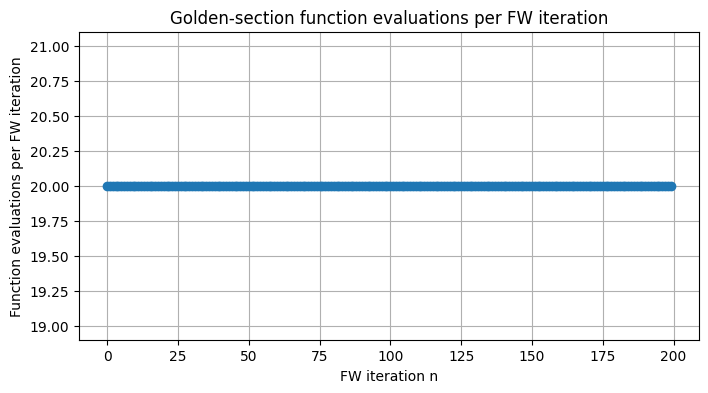

In [715]:
plt.figure(figsize=(8, 4))
plt.plot(history_golden["fw_iter"], history_golden["function_evals"], marker="o")
plt.xlabel("FW iteration n")
plt.ylabel("Function evaluations per FW iteration")
plt.title("Golden-section function evaluations per FW iteration")
plt.grid(True)
plt.show()

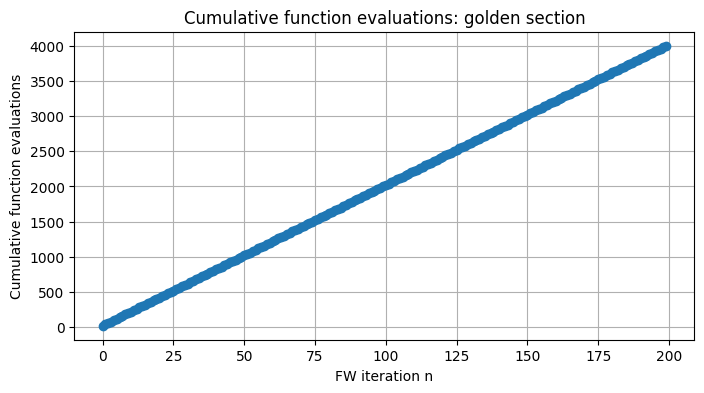

In [716]:
plt.figure(figsize=(8, 4))
plt.plot(history_golden["fw_iter"], history_golden["total_function_evals"], marker="o")
plt.xlabel("FW iteration n")
plt.ylabel("Cumulative function evaluations")
plt.title("Cumulative function evaluations: golden section")
plt.grid(True)
plt.show()

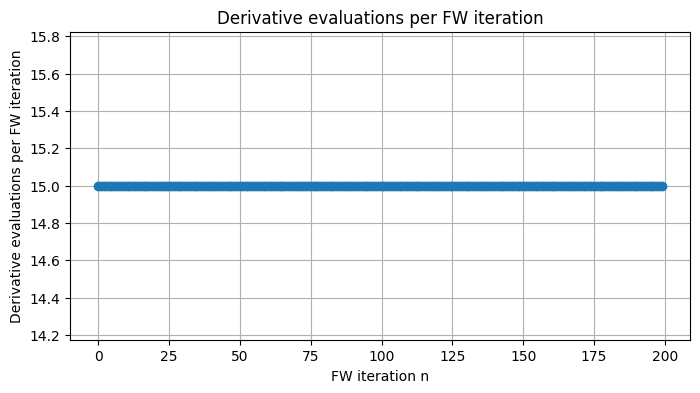

In [717]:
plt.figure(figsize=(8, 4))
plt.plot(history_bisection["fw_iter"], history_bisection["derivative_evals"], marker="o")
plt.xlabel("FW iteration n")
plt.ylabel("Derivative evaluations per FW iteration")
plt.title("Derivative evaluations per FW iteration")
plt.grid(True)
plt.show()

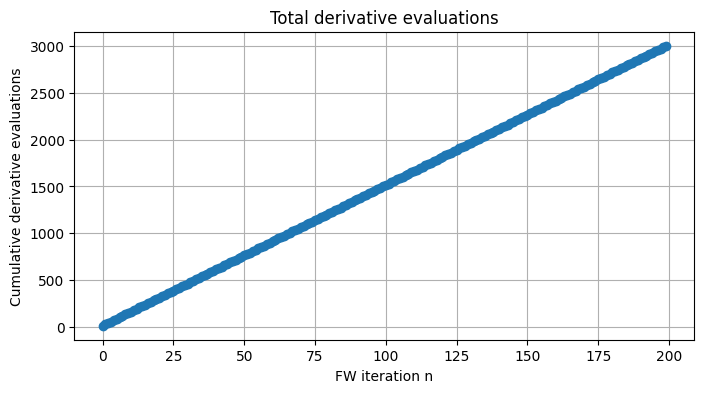

In [718]:
plt.figure(figsize=(8, 4))
plt.plot(history_bisection["fw_iter"], history_bisection["total_derivative_evals"], marker="o")
plt.xlabel("FW iteration n")
plt.ylabel("Cumulative derivative evaluations")
plt.title("Total derivative evaluations")
plt.grid(True)
plt.show()

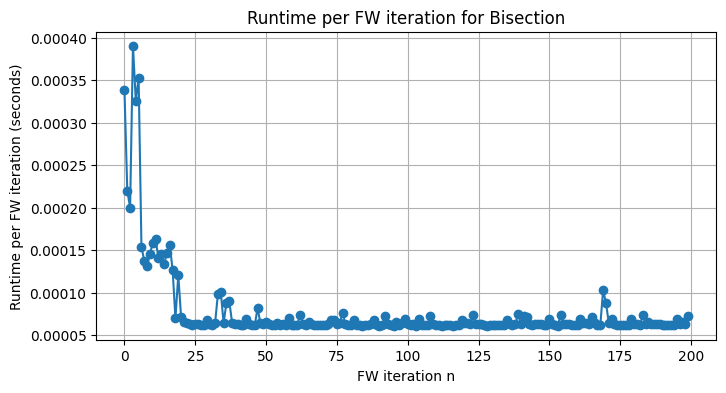

In [719]:
plt.figure(figsize=(8, 4))
plt.plot(history_bisection["fw_iter"], history_bisection["iter_runtime"], marker="o")
plt.xlabel("FW iteration n")
plt.ylabel("Runtime per FW iteration (seconds)")
plt.title("Runtime per FW iteration for Bisection")
plt.grid(True)
plt.show()

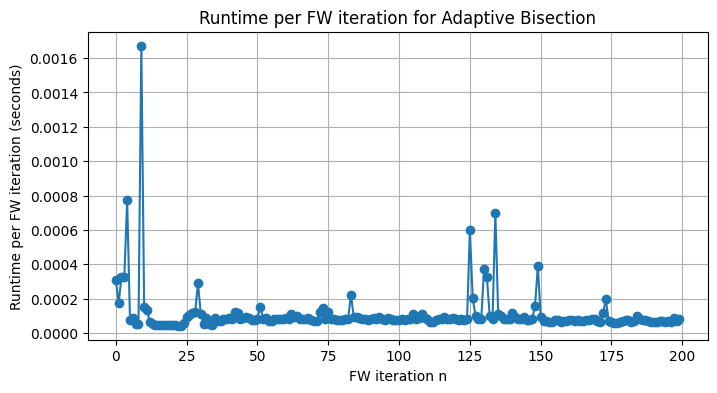

In [720]:
plt.figure(figsize=(8, 4))
plt.plot(history_adaptive_bisection["fw_iter"], history_adaptive_bisection["iter_runtime"], marker="o")
plt.xlabel("FW iteration n")
plt.ylabel("Runtime per FW iteration (seconds)")
plt.title("Runtime per FW iteration for Adaptive Bisection")
plt.grid(True)
plt.show()

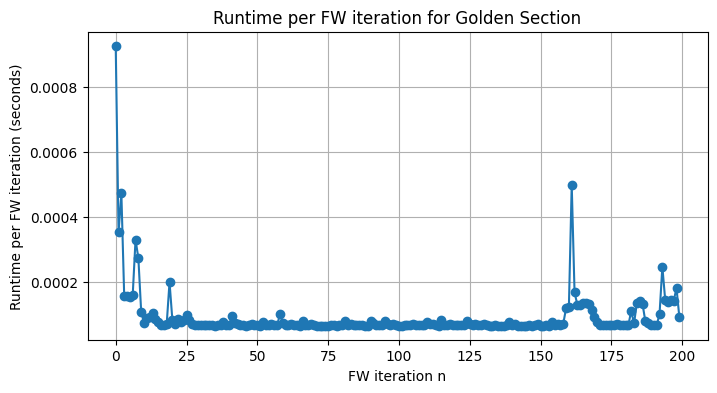

In [721]:
plt.figure(figsize=(8, 4))
plt.plot(history_golden["fw_iter"], history_golden["iter_runtime"], marker="o")
plt.xlabel("FW iteration n")
plt.ylabel("Runtime per FW iteration (seconds)")
plt.title("Runtime per FW iteration for Golden Section")
plt.grid(True)
plt.show()

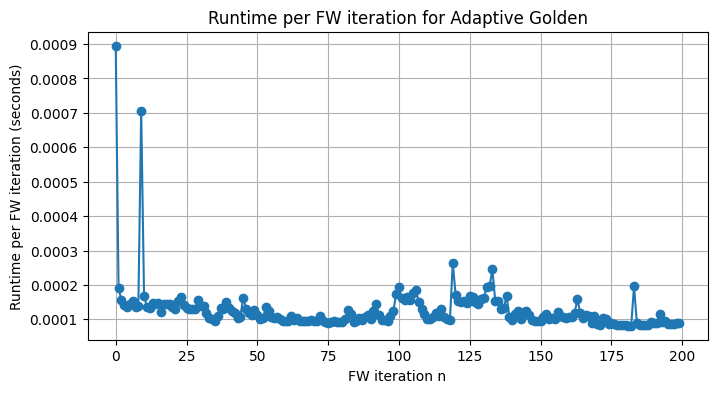

In [722]:
plt.figure(figsize=(8, 4))
plt.plot(history_adaptive_golden["fw_iter"], history_adaptive_golden["iter_runtime"], marker="o")
plt.xlabel("FW iteration n")
plt.ylabel("Runtime per FW iteration (seconds)")
plt.title("Runtime per FW iteration for Adaptive Golden")
plt.grid(True)
plt.show()

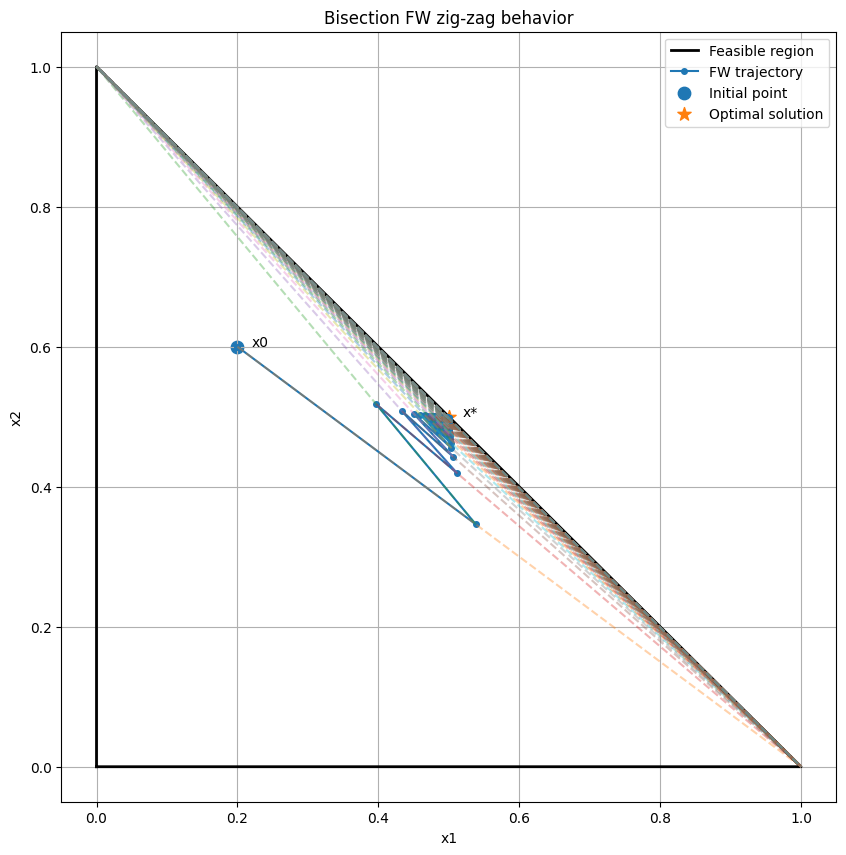

In [727]:
plt.figure(figsize=(10, 10))

# feasible region boundary
plt.plot([0, 1, 0, 0], [0, 0, 1, 0], "k-", linewidth=2, label="Feasible region")

# FW trajectory
plt.plot(
    history_bisection["x1"],
    history_bisection["x2"],
    marker="o",
    markersize=4,
    linewidth=1.5,
    label="FW trajectory"
)

# draw zig-zag search directions x^n -> y^n
for i in range(len(history_bisection)):
    x1_now = history_bisection.loc[i, "x1"]
    x2_now = history_bisection.loc[i, "x2"]
    y1_now = history_bisection.loc[i, "y1"]
    y2_now = history_bisection.loc[i, "y2"]

    plt.plot(
        [x1_now, y1_now],
        [x2_now, y2_now],
        linestyle="--",
        alpha=0.35
    )

# mark initial point
plt.scatter([history_bisection.loc[0, "x1"]], [history_bisection.loc[0, "x2"]], s=80, label="Initial point")
plt.text(history_bisection.loc[0, "x1"] + 0.02, history_bisection.loc[0, "x2"], "x0", fontsize=10)

# mark optimal solution
plt.scatter([0.5], [0.5], s=100, marker="*", label="Optimal solution")
plt.text(0.52, 0.50, "x*", fontsize=10)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Bisection FW zig-zag behavior")
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.show()

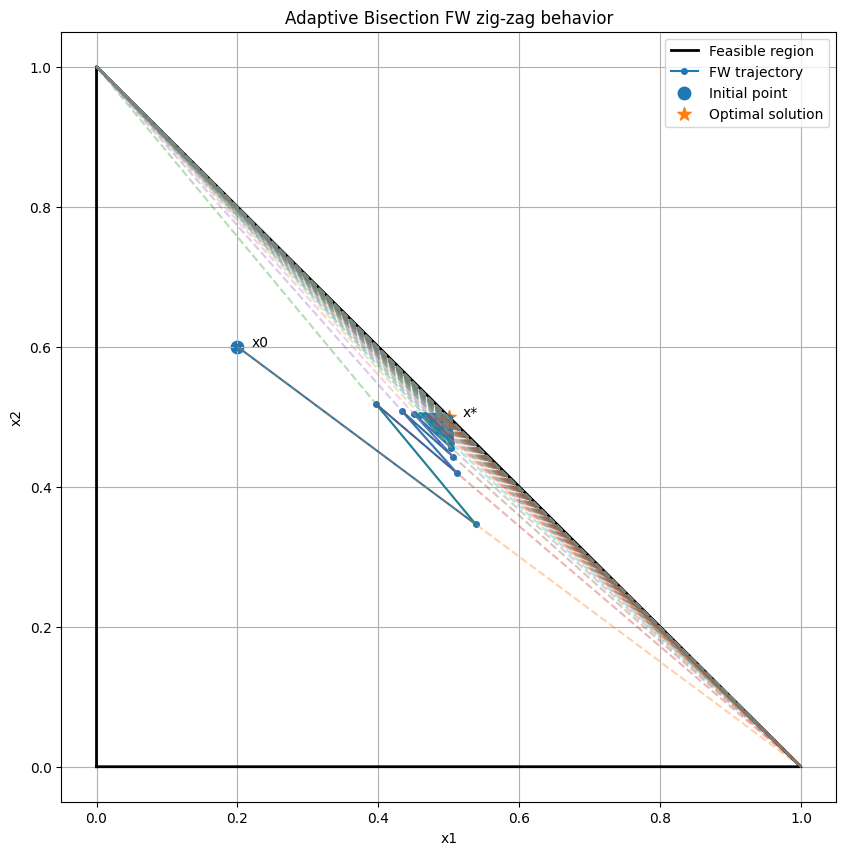

In [728]:
plt.figure(figsize=(10, 10))

# feasible region boundary
plt.plot([0, 1, 0, 0], [0, 0, 1, 0], "k-", linewidth=2, label="Feasible region")

# FW trajectory
plt.plot(
    history_adaptive_bisection["x1"],
    history_adaptive_bisection["x2"],
    marker="o",
    markersize=4,
    linewidth=1.5,
    label="FW trajectory"
)

# draw zig-zag search directions x^n -> y^n
for i in range(len(history_bisection)):
    x1_now = history_adaptive_bisection.loc[i, "x1"]
    x2_now = history_adaptive_bisection.loc[i, "x2"]
    y1_now = history_adaptive_bisection.loc[i, "y1"]
    y2_now = history_adaptive_bisection.loc[i, "y2"]

    plt.plot(
        [x1_now, y1_now],
        [x2_now, y2_now],
        linestyle="--",
        alpha=0.35
    )

# mark initial point
plt.scatter([history_adaptive_bisection.loc[0, "x1"]], [history_adaptive_bisection.loc[0, "x2"]], s=80, label="Initial point")
plt.text(history_adaptive_bisection.loc[0, "x1"] + 0.02, history_adaptive_bisection.loc[0, "x2"], "x0", fontsize=10)

# mark optimal solution
plt.scatter([0.5], [0.5], s=100, marker="*", label="Optimal solution")
plt.text(0.52, 0.50, "x*", fontsize=10)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Adaptive Bisection FW zig-zag behavior")
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.show()

In [729]:
def plot_bisection_zoom_overlay(
    history_bisection,
    history_adaptive_bisection,
    start_iter=0,
    end_iter=20,
    show_search_direction=False,
    padding_ratio=0.15,
    figsize=(8, 8)
):
    """
    Overlay fixed bisection and adaptive bisection FW trajectories
    in a zoomed region.

    Parameters
    ----------
    history_bisection:
        history table from fixed bisection

    history_adaptive_bisection:
        history table from adaptive bisection

    start_iter, end_iter:
        iteration range to zoom in

    show_search_direction:
        If True, also draw x^n -> y^n search directions.
        Usually keep False for comparison, otherwise the graph is messy.

    padding_ratio:
        extra margin around the zoomed points

    figsize:
        figure size
    """

    # Make sure both histories have comparable length
    max_len = min(len(history_bisection), len(history_adaptive_bisection))
    end_iter = min(end_iter, max_len - 1)

    fixed = history_bisection.iloc[start_iter:end_iter + 1].copy()
    adaptive = history_adaptive_bisection.iloc[start_iter:end_iter + 1].copy()

    plt.figure(figsize=figsize)

    # feasible region boundary
    plt.plot(
        [0, 1, 0, 0],
        [0, 0, 1, 0],
        "k-",
        linewidth=1.5,
        label="Feasible region"
    )

    # fixed bisection trajectory
    plt.plot(
        fixed["x1"],
        fixed["x2"],
        marker="o",
        markersize=6,
        linewidth=1.8,
        label="Fixed bisection"
    )

    # adaptive bisection trajectory
    plt.plot(
        adaptive["x1"],
        adaptive["x2"],
        marker="x",
        markersize=7,
        linewidth=1.8,
        linestyle="--",
        label="Adaptive bisection"
    )

    # connect points with the same FW iteration
    # This directly shows point-wise difference.
    for idx in range(len(fixed)):
        xf = fixed.iloc[idx]["x1"]
        yf = fixed.iloc[idx]["x2"]

        xa = adaptive.iloc[idx]["x1"]
        ya = adaptive.iloc[idx]["x2"]

        n = int(fixed.iloc[idx]["fw_iter"])

        plt.plot(
            [xf, xa],
            [yf, ya],
            linestyle=":",
            linewidth=1.0,
            alpha=0.6
        )

        # label selected iterations only, otherwise too crowded
        if idx == 0 or idx == len(fixed) - 1 or idx % 5 == 0:
            plt.text(
                xa + 0.001,
                ya + 0.001,
                str(n),
                fontsize=9
            )

    # optionally draw search directions x^n -> y^n
    if show_search_direction:
        for idx in range(len(fixed)):
            plt.plot(
                [fixed.iloc[idx]["x1"], fixed.iloc[idx]["y1"]],
                [fixed.iloc[idx]["x2"], fixed.iloc[idx]["y2"]],
                linestyle="--",
                alpha=0.18
            )

            plt.plot(
                [adaptive.iloc[idx]["x1"], adaptive.iloc[idx]["y1"]],
                [adaptive.iloc[idx]["x2"], adaptive.iloc[idx]["y2"]],
                linestyle=":",
                alpha=0.18
            )

    # optimal solution
    plt.scatter(
        [0.5],
        [0.5],
        s=120,
        marker="*",
        label="Optimal solution"
    )

    # automatic zoom range based on selected points
    all_x = np.concatenate([
        fixed["x1"].to_numpy(),
        adaptive["x1"].to_numpy(),
        np.array([0.5])
    ])

    all_y = np.concatenate([
        fixed["x2"].to_numpy(),
        adaptive["x2"].to_numpy(),
        np.array([0.5])
    ])

    x_min, x_max = all_x.min(), all_x.max()
    y_min, y_max = all_y.min(), all_y.max()

    x_span = max(x_max - x_min, 1e-4)
    y_span = max(y_max - y_min, 1e-4)

    plt.xlim(x_min - padding_ratio * x_span, x_max + padding_ratio * x_span)
    plt.ylim(y_min - padding_ratio * y_span, y_max + padding_ratio * y_span)

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(
        f"Zoomed FW zig-zag: fixed vs adaptive bisection "
        f"(iterations {start_iter}–{end_iter})"
    )
    plt.grid(True)
    plt.legend()
    plt.show()

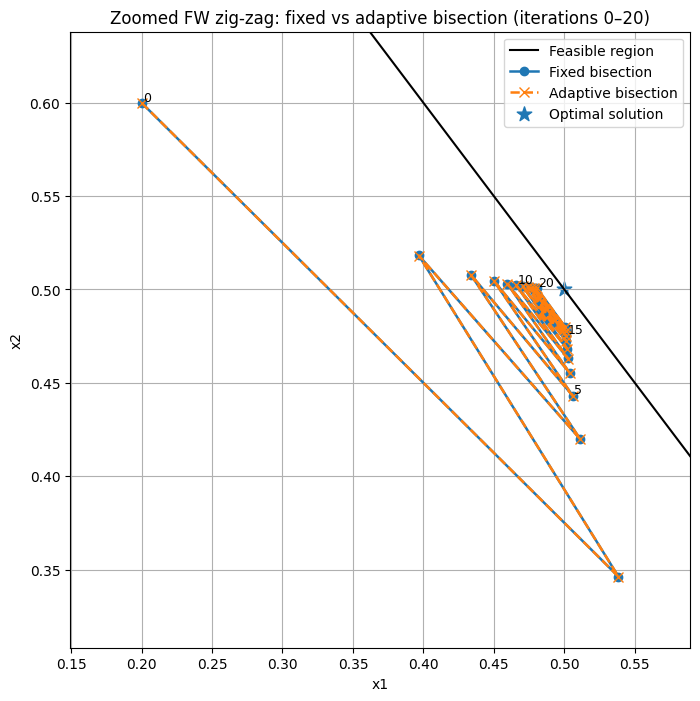

In [730]:
plot_bisection_zoom_overlay(
    history_bisection,
    history_adaptive_bisection,
    start_iter=0,
    end_iter=20,
    show_search_direction=False,
    figsize=(8, 8)
)

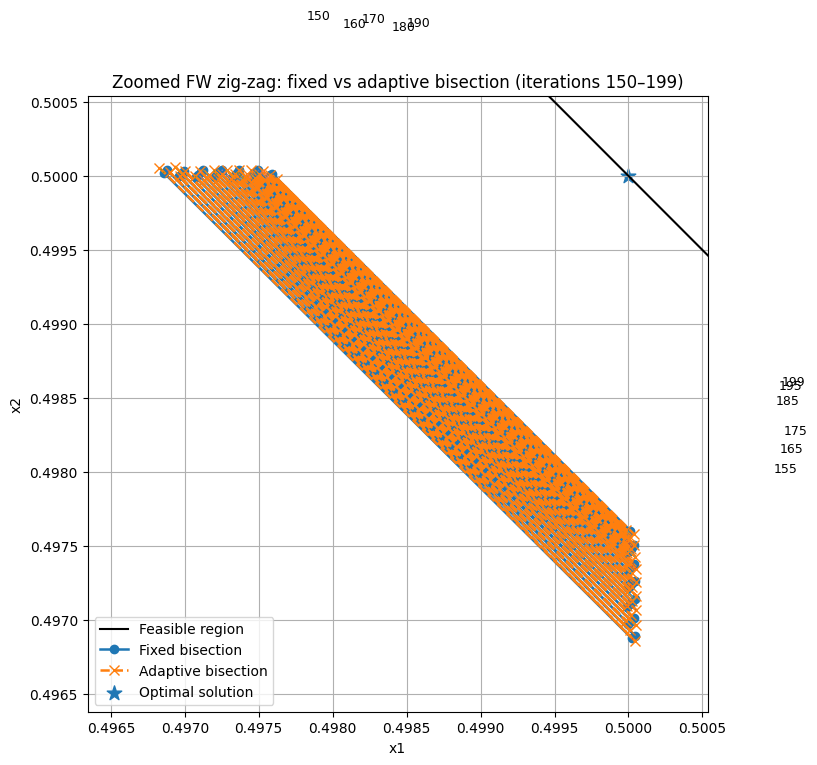

In [731]:
plot_bisection_zoom_overlay(
    history_bisection,
    history_adaptive_bisection,
    start_iter=150,
    end_iter=199,
    show_search_direction=False,
    figsize=(8, 8)
) #这里说明基本看不出端点处的细微区别

In [732]:
# 找两个方法每一轮的点位距离
def compare_bisection_points(history_bisection, history_adaptive_bisection):
    n = min(len(history_bisection), len(history_adaptive_bisection))

    fixed = history_bisection.iloc[:n].reset_index(drop=True)
    adaptive = history_adaptive_bisection.iloc[:n].reset_index(drop=True)

    compare = pd.DataFrame({
        "fw_iter": fixed["fw_iter"],

        "fixed_x1": fixed["x1"],
        "fixed_x2": fixed["x2"],
        "fixed_x3": fixed["x3"],

        "adaptive_x1": adaptive["x1"],
        "adaptive_x2": adaptive["x2"],
        "adaptive_x3": adaptive["x3"],

        "fixed_alpha": fixed["alpha"],
        "adaptive_alpha": adaptive["alpha"],
    })

    compare["dx1"] = compare["adaptive_x1"] - compare["fixed_x1"]
    compare["dx2"] = compare["adaptive_x2"] - compare["fixed_x2"]
    compare["dx3"] = compare["adaptive_x3"] - compare["fixed_x3"]

    compare["point_distance_x1x2"] = np.sqrt(
        compare["dx1"]**2 + compare["dx2"]**2
    )

    compare["point_distance_x123"] = np.sqrt(
        compare["dx1"]**2 + compare["dx2"]**2 + compare["dx3"]**2
    )

    compare["alpha_diff"] = compare["adaptive_alpha"] - compare["fixed_alpha"]

    return compare


compare_bis = compare_bisection_points(
    history_bisection,
    history_adaptive_bisection
)

display(compare_bis.head(10))
display(compare_bis.tail(10))

print("max |dx1|:", compare_bis["dx1"].abs().max())
print("max |dx2|:", compare_bis["dx2"].abs().max())
print("max x1-x2 distance:", compare_bis["point_distance_x1x2"].max())
print("mean x1-x2 distance:", compare_bis["point_distance_x1x2"].mean())
print("max |alpha diff|:", compare_bis["alpha_diff"].abs().max())

,fw_iter,fixed_x1,fixed_x2,fixed_x3,adaptive_x1,adaptive_x2,adaptive_x3,fixed_alpha,adaptive_alpha,dx1,dx2,dx3,point_distance_x1x2,point_distance_x123,alpha_diff
0,0,0.200000,0.600000,0.200000,0.200000,0.600000,0.200000,0.423035,0.423035,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,0.538428,0.346179,0.115393,0.538428,0.346179,0.115393,0.263123,0.263106,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000017
2,2,0.396755,0.518214,0.085031,0.396764,0.518203,0.085032,0.189880,0.189814,0.000009,-0.000011,0.000002,0.000014,0.000014,-0.000067
3,3,0.511300,0.419815,0.068885,0.511267,0.419841,0.068892,0.151794,0.151721,-0.000033,0.000026,0.000007,0.000042,0.000042,-0.000073
4,4,0.433687,0.507884,0.058429,0.433697,0.507864,0.058440,0.127502,0.127496,0.000010,-0.000021,0.000011,0.000023,0.000025,-0.000006
5,5,0.505893,0.443128,0.050979,0.505898,0.443113,0.050989,0.110291,0.110376,0.000005,-0.000015,0.000010,0.000016,0.000019,0.000086
6,6,0.450098,0.504546,0.045356,0.450059,0.504580,0.045361,0.097473,0.097496,-0.000039,0.000034,0.000005,0.000052,0.000052,0.000022
7,7,0.503699,0.455366,0.040935,0.503676,0.455386,0.040938,0.087585,0.087498,-0.000023,0.000020,0.000003,0.000030,0.000031,-0.000087
8,8,0.459582,0.503068,0.037350,0.459605,0.503039,0.037356,0.079529,0.079552,0.000023,-0.000029,0.000006,0.000037,0.000038,0.000023
9,9,0.502561,0.463060,0.034380,0.502594,0.463021,0.034385,0.072815,0.072948,0.000033,-0.000039,0.000005,0.000051,0.000051,0.000133


,fw_iter,fixed_x1,fixed_x2,fixed_x3,adaptive_x1,adaptive_x2,adaptive_x3,fixed_alpha,adaptive_alpha,dx1,dx2,dx3,point_distance_x1x2,point_distance_x123,alpha_diff
190,190,0.497481,0.500027,0.002491,0.497502,0.500010,0.002488,0.005066,0.004952,2.059220e-05,-1.768381e-05,-0.000003,0.000027,0.000027,-0.000114
191,191,0.500027,0.497494,0.002479,0.499990,0.497534,0.002476,0.005066,0.004875,-3.675882e-05,3.936898e-05,-0.000003,0.000054,0.000054,-0.000191
192,192,0.497494,0.500040,0.002466,0.497553,0.499983,0.002464,0.005066,0.004951,5.907510e-05,-5.695184e-05,-0.000002,0.000082,0.000082,-0.000115
193,193,0.500040,0.497507,0.002454,0.500041,0.497508,0.002452,0.004944,0.005028,9.275018e-07,9.013111e-07,-0.000002,0.000001,0.000002,0.000084
194,194,0.497567,0.499991,0.002442,0.497526,0.500034,0.002440,0.004822,0.004950,-4.122706e-05,4.325350e-05,-0.000002,0.000060,0.000060,0.000128
195,195,0.499990,0.497580,0.002430,0.500013,0.497559,0.002427,0.004822,0.004872,2.318723e-05,-2.085879e-05,-0.000002,0.000031,0.000031,0.000050
196,196,0.497579,0.500003,0.002418,0.497577,0.500007,0.002416,0.004822,0.004796,-2.156044e-06,4.595748e-06,-0.000002,0.000005,0.000006,-0.000026
197,197,0.500002,0.497592,0.002406,0.499987,0.497609,0.002404,0.004822,0.004721,-1.504140e-05,1.740734e-05,-0.000002,0.000023,0.000023,-0.000101
198,198,0.497591,0.500014,0.002395,0.497626,0.499981,0.002393,0.004822,0.004795,3.533297e-05,-3.322030e-05,-0.000002,0.000048,0.000049,-0.000027
199,199,0.500013,0.497603,0.002383,0.500035,0.497584,0.002381,0.004822,0.004870,2.167987e-05,-1.964160e-05,-0.000002,0.000029,0.000029,0.000048


max |dx1|: 8.201276686065073e-05
max |dx2|: 7.738935400702918e-05
max x1-x2 distance: 0.00011276172241396783
mean x1-x2 distance: 3.173235619003418e-05
max |alpha diff|: 0.0001943302281099124


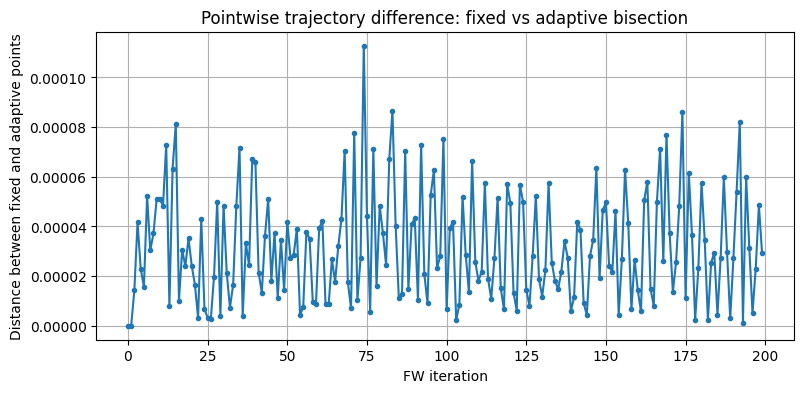

In [733]:
# 两个方法每一轮的点位距离
plt.figure(figsize=(9, 4))

plt.plot(
    compare_bis["fw_iter"],
    compare_bis["point_distance_x1x2"],
    marker="o",
    markersize=3,
    linewidth=1.5
)

plt.xlabel("FW iteration")
plt.ylabel("Distance between fixed and adaptive points")
plt.title("Pointwise trajectory difference: fixed vs adaptive bisection")
plt.grid(True)
plt.show()